In [2]:
import pandas as pd

sample = pd.read_csv("ESSQSS20.csv", nrows=5)
print(f"Total columns in file: {len(sample.columns)}")
print(f"\nFirst 30 column names:")
print(sample.columns.tolist()[:30])
sample.head()

Total columns in file: 2752

First 30 column names:
['name', 'essround', 'edition', 'proddate', 'idno', 'cntry', 'dweight', 'pspwght', 'pweight', 'anweight', 'prob', 'stratum', 'psu', 'netuse', 'netusoft', 'netustm', 'nwspol', 'nwsppol', 'nwsptot', 'pplfair', 'pplhlp', 'ppltrst', 'rdpol', 'rdtot', 'tvpol', 'tvtot', 'actrolg', 'actrolga', 'badge', 'bctprd']


,name,essround,edition,proddate,idno,cntry,dweight,pspwght,pweight,anweight,...,hrshsnt,hrshsnta,mnrgtjb,pdaprp,pdaprpa,slprl,smbtjob,smbtjoba,stfjbot,wrhpp
0,ESS1e06_7,1,6.7,23.11.2023,1,AT,0.9452,0.940933,0.271487,0.255451,...,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN,NaN,NaN
1,ESS1e06_7,1,6.7,23.11.2023,2,AT,0.4726,0.470466,0.271487,0.127726,...,NaN,NaN,NaN,NaN,NaN,NaN,66,NaN,NaN,NaN
2,ESS1e06_7,1,6.7,23.11.2023,3,AT,0.9452,1.392155,0.271487,0.377953,...,NaN,NaN,NaN,NaN,NaN,NaN,66,NaN,NaN,NaN
3,ESS1e06_7,1,6.7,23.11.2023,4,AT,0.9452,1.382163,0.271487,0.375240,...,NaN,NaN,NaN,NaN,NaN,NaN,5,NaN,NaN,NaN
4,ESS1e06_7,1,6.7,23.11.2023,6,AT,1.8905,1.437766,0.271487,0.390336,...,NaN,NaN,NaN,NaN,NaN,NaN,66,NaN,NaN,NaN


In [3]:
# Load only the columns we'll actually use for the viz
cols_needed = [
    'cntry',      # country code
    'essround',   # ESS round (1-9)
    'imbgeco',    # immigration good for economy (0-10)
    'imueclt',    # immigrants enrich culture (0-10)
    'imwbcnt',    # immigrants make country better (0-10)
    'agea',       # age
    'eduyrs',     # years of education
    'ctzcntr',    # citizen of country (1=yes, 2=no)
    'brncntr'     # born in country (1=yes, 2=no)
]

ess = pd.read_csv("ESSQSS20.csv", usecols=cols_needed)
print(f"Loaded shape: {ess.shape}")
print(f"\nMissing values per column:")
print(ess.isna().sum())
ess.head()

Loaded shape: (540671, 9)

Missing values per column:
essround    0
cntry       0
imbgeco     0
imueclt     0
imwbcnt     0
brncntr     0
ctzcntr     0
agea        0
eduyrs      0
dtype: int64


,essround,cntry,imbgeco,imueclt,imwbcnt,brncntr,ctzcntr,agea,eduyrs
0,1,AT,4,9,7,1,1,54,11.0
1,1,AT,10,10,5,1,1,50,14.0
2,1,AT,7,5,5,1,1,63,9.0
3,1,AT,10,10,10,1,1,44,18.0
4,1,AT,88,88,88,1,1,41,15.0


In [10]:
# ESS codes "Don't know" / "Refused" / "No answer" as values >10 on the 0-10 scale
# Set these to NaN so they don't pollute the average
attitude_cols = ['imbgeco', 'imueclt', 'imwbcnt']
for col in attitude_cols:
    ess.loc[ess[col] > 10, col] = pd.NA

# Filter to native-born respondents only (brncntr == 1 means "yes, born in country")
ess_native = ess[ess['brncntr'] == 1].copy()

# Build the pro-immigration attitude index (mean of the three 0-10 questions)
ess_native['immig_attitude'] = ess_native[attitude_cols].mean(axis=1)

# Drop rows missing the attitude index
ess_native = ess_native.dropna(subset=['immig_attitude'])

print(f"After cleaning: {ess_native.shape}")
print(f"\nMean attitude by ESS round:")
print(ess_native.groupby('essround')['immig_attitude'].mean().round(2))

After cleaning: (481234, 10)

Mean attitude by ESS round:
essround
1     5.05
2     4.86
3     4.97
4     4.88
5     4.75
6     5.02
7     5.09
8     4.98
9     5.11
10    5.27
11    5.12
Name: immig_attitude, dtype: float64


In [18]:
country_round_means = (
    ess_native
    .groupby(['cntry', 'essround'])['immig_attitude']
    .mean()
    .reset_index()
)

round_to_year = {1: 2002, 2: 2004, 3: 2006, 4: 2008, 5: 2010,
                 6: 2012, 7: 2014, 8: 2016, 9: 2018,
                 10: 2020, 11: 2023}
country_round_means['year'] = country_round_means['essround'].map(round_to_year)

print(f"Country-round means: {country_round_means.shape}")
country_round_means.head(10)

Country-round means: (289, 4)


,cntry,essround,immig_attitude,year
0,AL,6,5.830940,2012
1,AT,1,5.252310,2002
2,AT,2,4.777859,2004
3,AT,3,4.680505,2006
4,AT,7,4.503378,2014
5,AT,8,4.363291,2016
6,AT,9,4.696123,2018
7,AT,10,4.785714,2020
8,AT,11,4.832310,2023
9,BE,1,4.838557,2002


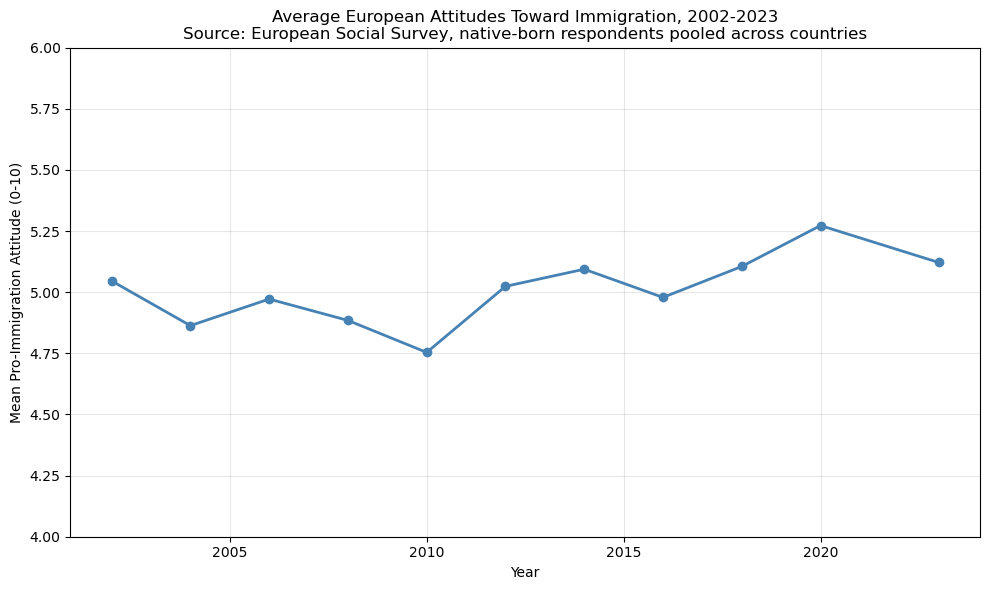

In [19]:
import matplotlib.pyplot as plt

overall_by_round = (
    ess_native
    .groupby('essround')['immig_attitude']
    .mean()
    .reset_index()
)
overall_by_round['year'] = overall_by_round['essround'].map(round_to_year)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(overall_by_round['year'], overall_by_round['immig_attitude'],
        marker='o', linewidth=2, color='steelblue')
ax.set_xlabel('Year')
ax.set_ylabel('Mean Pro-Immigration Attitude (0-10)')
ax.set_title('Average European Attitudes Toward Immigration, 2002-2023\nSource: European Social Survey, native-born respondents pooled across countries')
ax.grid(True, alpha=0.3)
ax.set_ylim(4, 6)
plt.tight_layout()
plt.savefig('viz1_european_mean_over_time.png', dpi=150, bbox_inches='tight')
plt.show()
plt.show()

Round 6 (2012): 29 countries


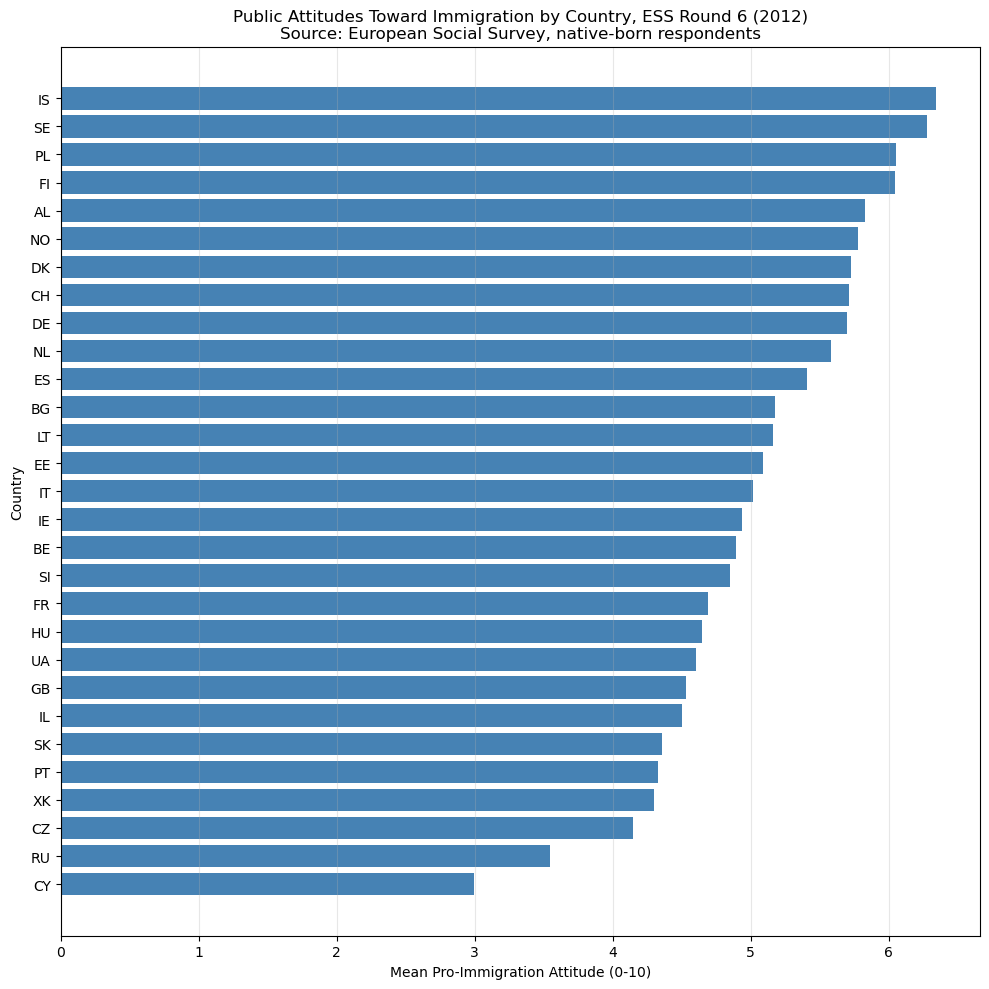

In [20]:
target_round = 6
target_year = round_to_year[target_round]

plot_data = (
    country_round_means[country_round_means['essround'] == target_round]
    .sort_values('immig_attitude', ascending=True)
)

print(f"Round {target_round} ({target_year}): {len(plot_data)} countries")

fig, ax = plt.subplots(figsize=(10, 10))
ax.barh(plot_data['cntry'], plot_data['immig_attitude'], color='steelblue')
ax.set_xlabel('Mean Pro-Immigration Attitude (0-10)')
ax.set_ylabel('Country')
ax.set_title(f'Public Attitudes Toward Immigration by Country, ESS Round {target_round} ({target_year})\nSource: European Social Survey, native-born respondents')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('viz2_attitudes_by_country.png', dpi=150, bbox_inches='tight')
plt.show()
